# Ensemble Affinity Analysis (On-the-fly)

This notebook computes PRP and RA summaries in memory from merged benchmark files.

No summary CSVs are created and figures are shown inline only.

In [10]:
from pathlib import Path
import pandas as pd
import numpy as np
import plotly.express as px

import sys
scripts_dir = (Path.cwd().resolve().parent / "scripts") if Path.cwd().name == "notebooks" else (Path.cwd().resolve() / "scripts")
if str(scripts_dir) not in sys.path:
    sys.path.append(str(scripts_dir))

from run_affinity_adjudication import (
    # compute_pair_stats,
    normalize_abstract_index,
    affinity_level_fixed,
 )


**Bucket definitions & pairing rules**
- **Bucket A (Within-level):** both abstracts have the same majority affinity level (e.g., both Moderate or both High).
- **Bucket B (Cross-boundary — Diagnostic):** one abstract majority = Moderate, the other = High.
- **Bucket C (Skip-level):** one abstract majority = Low, the other = High.

**Pair selection rules**
- Work per `RA2025_ID`. Consider only abstracts whose *ensemble* level is Moderate or High.
- Form all unordered pairs (i, j) within the same `RA2025_ID`.
- Keep pairs only if |ensemble_mean_i - ensemble_mean_j| >= 5 points.

**Per-model ranking & consensus**
- Per-model rank `rank_m(i,j)`: +1 if score_i > score_j, -1 if score_i < score_j, 0 if equal.
- Only count models that provided numeric scores for both abstracts; `n_models_pair` may vary by pair.
- `rank_consensus = abs(sum(rank_m)) / n_models_pair` (0 = split vote, 1 = unanimity). >0.67 ≈ 5/6 agreement.

**Majority label assignment**
- Apply `affinity_level_fixed(score)` per model (Low 0–40, Moderate 40–70, High 70–100).
- Majority label = most frequent per-model label; tie-breaker: choose higher level. Exclude unresolved cases.

**Diagnostics / expectations**
- Hypothesis A (coherent ranking): Bucket A ≈ Bucket B and both ≳ 0.7; Bucket C rare.
- Hypothesis B (boundary instability): Bucket A moderate, Bucket B ≈ 0.5, Bucket C frequent.

In [ ]:
# Set run_id explicitly, or keep None to use latest run folder.
ignore_models = ['smollm2-1.7b', 'gemma3-4b', 'phi3-3.8b']
run_id =None
# run_id = "20260401_082538"
# run_id = "20260406_211752"
# run_id = "20260413_151017"
# run_id = "20260422_212121"
run_id = "20260517_175302"

repo_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
bench_root = repo_root / "data" / "results" / "affinity_benchmark"

if run_id is None:
    run_dirs = sorted([p for p in bench_root.iterdir() if p.is_dir()])
    if not run_dirs:
        raise FileNotFoundError(f"No benchmark runs found under {bench_root}")
    run_dir = run_dirs[-1]
else:
    run_dir = bench_root / run_id

prp_path = run_dir / "merged_prp_affinities.csv"
ra_path = run_dir / "merged_ra_affinities.csv"

if not prp_path.exists() :
    raise FileNotFoundError(
        "Merged files not found. Run scripts/run_postprocessing.py first for this run_id."
    )
prp_df = pd.read_csv(prp_path)
prp_df = prp_df[~prp_df['Model_Slug'].isin(ignore_models)]

print("Run directory:", run_dir)
print("PRP rows:", len(prp_df), "| Models:", prp_df['Model_Slug'].nunique())
if ra_path.exists():
    ra_df = pd.read_csv(ra_path)
    ra_df = ra_df[~ra_df['Model_Slug'].isin(ignore_models)]
    print("RA rows:", len(ra_df), "| Models:", ra_df['Model_Slug'].nunique())






Run directory: /mnt/c/Users/pgallego/OneDrive - Imperial College London/PhD/Repositories/article-classifier/data/results/affinity_benchmark/20260422_212121
PRP rows: 3600 | Models: 6
RA rows: 28449 | Models: 6


In [12]:
# Intra-panel rank agreement analysis
from collections import Counter
import itertools
import os

# Ensure `ra_df` was loaded by previous cells
if 'ra_df' not in globals():
    raise RuntimeError("ra_df not found. Ensure merged_ra_affinities.csv was loaded above.")

# Prepare data
ra_df['LLM_Affinity'] = pd.to_numeric(ra_df['LLM_Affinity'], errors='coerce')
ra_df = ra_df.dropna(subset=['LLM_Affinity']).copy()
ra_df['Abstract_Index_Norm'] = ra_df['Abstract_Index'].apply(normalize_abstract_index)

# Ensemble mean per abstract (by RA question)
ensemble = (
    ra_df
    .groupby(['RA2025_ID','Abstract_Index_Norm','Document Title'], dropna=False, as_index=False)
    .agg(Affinity_Mean=('LLM_Affinity','mean'), N_Models=('LLM_Affinity','count'))
)
ensemble['Ensemble_Level'] = ensemble['Affinity_Mean'].apply(affinity_level_fixed)

# Merge ensemble info back to model rows (optional)
ra_with_ensemble = ra_df.merge(ensemble[['RA2025_ID','Abstract_Index_Norm','Affinity_Mean','Ensemble_Level']], on=['RA2025_ID','Abstract_Index_Norm'], how='left')

# Select abstracts whose ensemble-level is Moderate or High
sel = ensemble[ensemble['Ensemble_Level'].isin(['Moderate','High'])].copy()

out_rows = []
for ra_id, grp in sel.groupby('RA2025_ID'):
    abstracts = grp[['Abstract_Index_Norm','Affinity_Mean','Document Title']].drop_duplicates()
    abs_map = {r['Abstract_Index_Norm']:(r['Affinity_Mean'], r['Document Title']) for _,r in abstracts.iterrows()}
    abs_list = list(abs_map.keys())
    for a,b in itertools.combinations(abs_list,2):
        mean_a = abs_map[a][0]; mean_b = abs_map[b][0]
        mean_diff = abs(mean_a - mean_b)
        if mean_diff < 5:
            continue
        # per-model scores for this ra_id and abstracts a,b
        sub = ra_df[ra_df['RA2025_ID']==ra_id]
        piv = sub.pivot_table(index='Model_Slug', columns='Abstract_Index_Norm', values='LLM_Affinity', aggfunc='first')
        # require models that provided both scores
        if (a not in piv.columns) or (b not in piv.columns):
            continue
        models_both = piv.index[piv[a].notna() & piv[b].notna()]
        if len(models_both)==0:
            continue
        per_model_ranks = {}
        sum_rank = 0
        for m in models_both:
            sa = piv.at[m,a]; sb = piv.at[m,b]
            if sa > sb:
                r = 1
            elif sa < sb:
                r = -1
            else:
                r = 0
            per_model_ranks[m]=r
            sum_rank += r
        n_models_pair = len(models_both)
        rank_consensus = abs(sum_rank)/n_models_pair if n_models_pair>0 else None

        # majority labels per abstract (tie-breaker: higher level)
        def majority_label(abs_idx):
            sub2 = ra_df[(ra_df['RA2025_ID']==ra_id) & (ra_df['Abstract_Index_Norm']==abs_idx)]
            labels = sub2['LLM_Affinity'].apply(affinity_level_fixed).dropna().tolist()
            if not labels:
                return None
            counts = Counter(labels)
            most_common = counts.most_common()
            top_count = most_common[0][1]
            top_labels = [lab for lab,c in most_common if c==top_count]
            order = {'Low':0,'Moderate':1,'High':2}
            top_labels_sorted = sorted(top_labels, key=lambda x:order.get(x, -1), reverse=True)
            return top_labels_sorted[0]

        lab_a = majority_label(a)
        lab_b = majority_label(b)
        if lab_a is None or lab_b is None:
            bucket = None
        elif lab_a == lab_b:
            bucket = 'A'
        elif set([lab_a,lab_b])==set(['Moderate','High']):
            bucket = 'B'
        elif set([lab_a,lab_b])==set(['Low','High']):
            bucket = 'C'
        else:
            bucket = None

        out_rows.append({
            'RA2025_ID': ra_id,
            'abstract_i': a,
            'abstract_j': b,
            'title_i': abs_map[a][1],
            'title_j': abs_map[b][1],
            'mean_i': mean_a,
            'mean_j': mean_b,
            'mean_diff': mean_diff,
            'n_models_pair': n_models_pair,
            'rank_consensus': rank_consensus,
            'bucket': bucket,
            'per_model_ranks': per_model_ranks,
        })

out_df = pd.DataFrame(out_rows)
out_df = out_df.dropna(subset=['bucket']).copy()

agg = out_df.groupby('bucket').agg(counts=('rank_consensus','size'), mean_rank_consensus=('rank_consensus','mean')).reset_index()
print('Aggregated results:')
print(agg)

# Save outputs
out_dir = repo_root / 'notebooks' / 'outputs' / 'intra_panel_rank_agreement' / run_dir.name
out_dir.mkdir(parents=True, exist_ok=True)
out_df.to_csv(out_dir / 'pairwise_rank_consensus.csv', index=False)
agg.to_csv(out_dir / 'bucket_aggregate.csv', index=False)

# show some Bucket B examples for inspection
if 'display' in globals():
    try:
        display(out_df[out_df['bucket']=='B'].sort_values('rank_consensus', ascending=False).head(10))
    except Exception:
        print(out_df[out_df['bucket']=='B'].sort_values('rank_consensus', ascending=False).head(10))
else:
    print(out_df[out_df['bucket']=='B'].sort_values('rank_consensus', ascending=False).head(10))

Aggregated results:
  bucket  counts  mean_rank_consensus
0      A    2473             0.548376
1      B    2276             0.787251
2      C     542             0.812362
      RA2025_ID abstract_i abstract_j  \
5768         47         32         98   
2             1        100         39   
5699         45         63         95   
5702         45         95         99   
5704         46         10         32   
5705         46         10         55   
5706         46         10          6   
5684         45         21         95   
5644         43          3         75   
5645         43          3         81   

                                                title_i  \
5768  Ecological Robustness-Oriented Grid Network De...   
2     Optimal Energy Utilization of MMC-HVDC System ...   
5699  Tractable Data Enriched Distributionally Robus...   
5702  A Multitask Integrated Deep-Learning Probabili...   
5704  Achieving Emission-Reduction Goals: Multi-Peri...   
5705  Achieving Emissi

Total pairs: 5291


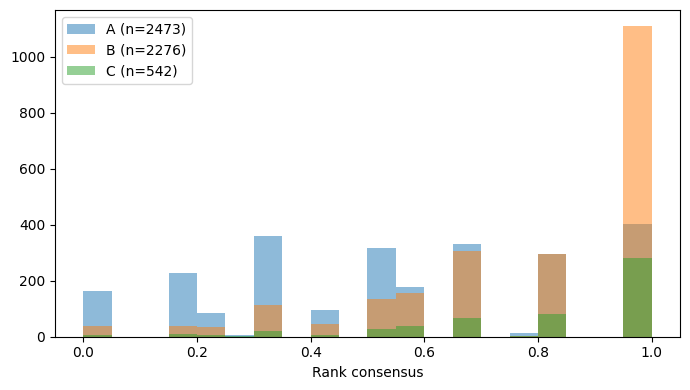

<Figure size 600x400 with 0 Axes>

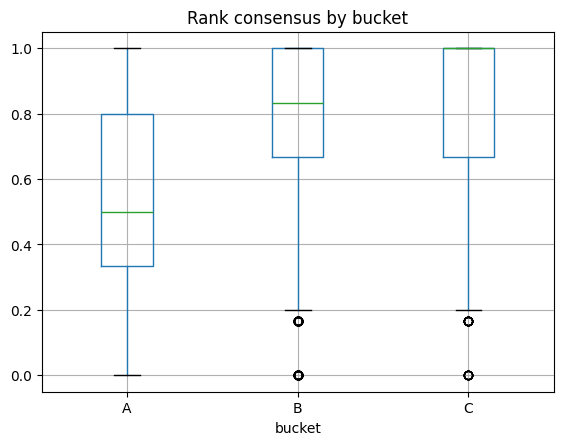


Top Bucket B pairs:
      RA2025_ID  abstract_i  abstract_j     mean_i     mean_j  mean_diff  \
5285         47          32          98  76.500000  42.000000  34.500000   
2             1         100          39  71.000000  40.500000  30.500000   
5220         45          63          95  42.000000  83.800000  41.800000   
5223         45          95          99  83.800000  55.400000  28.400000   
5225         46          10          32  44.166667  92.333333  48.166667   
5226         46          10          55  44.166667  83.000000  38.833333   
5227         46          10           6  44.166667  70.833333  26.666667   
5207         45          21          95  41.666667  83.800000  42.133333   
5169         43           3          75  79.333333  60.833333  18.500000   
5170         43           3          81  79.333333  55.500000  23.833333   

      n_models_pair  rank_consensus  
5285              5             1.0  
2                 5             1.0  
5220              5         

In [13]:
# Visualize bucket distributions and show example Bucket B pairs
import matplotlib.pyplot as plt
pair_csv = repo_root / 'notebooks' / 'outputs' / 'intra_panel_rank_agreement' / run_dir.name / 'pairwise_rank_consensus.csv'
df = pd.read_csv(pair_csv)
print('Total pairs:', len(df))

plt.figure(figsize=(7,4))
for b in ['A','B','C']:
    subset = df[df['bucket']==b]['rank_consensus']
    plt.hist(subset, bins=20, alpha=0.5, label=f'{b} (n={len(subset)})')
plt.xlabel('Rank consensus')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
df_box = df[df['bucket'].isin(['A','B','C'])]
df_box.boxplot(column='rank_consensus', by='bucket')
plt.title('Rank consensus by bucket')
plt.suptitle('')
plt.show()

print('\nTop Bucket B pairs:')
topB = df[df['bucket']=='B'].sort_values('rank_consensus', ascending=False).head(10)
print(topB[['RA2025_ID','abstract_i','abstract_j','mean_i','mean_j','mean_diff','n_models_pair','rank_consensus']])

### Interpreting Each Bucket
Bucket B at 0.787 — models have coherent Moderate/High rank ordering
This is good news for calibration. When one abstract is majority-voted Moderate and another High, models agree on which is higher 79% of the time. The boundary between Moderate and High is semantically real to the models — they just cannot agree on where exactly to place the threshold. This is consistent with Hypothesis A.

Bucket C at 0.812 — Low vs High is the clearest signal in your data
This is expected and confirms the binary irrelevance signal you already observed. Models have a strong shared representation of irrelevance vs relevance. The interesting point is that this is only marginally higher than Bucket B, meaning the Moderate/High distinction is almost as sharp as the Low/High distinction in rank terms.

Bucket A at 0.548 — within-level pairs are nearly random
This is the unexpected and most important finding. When two abstracts are both assigned the same level by majority vote, models barely agree on which one scores higher. This is close to chance (0.5).
This means the problem is not at the boundaries between levels — it is within levels. Models agree that abstract X is Moderate and abstract Y is also Moderate, but have no consistent view on whether X or Y is more Moderate. The scoring within a category is essentially noise.

### The Revised Diagnosis
This pattern is consistent with a specific failure mode: models are using the level labels as attractors rather than producing continuous affinity scores that happen to map onto levels. In other words, the score is not a true continuous measurement of affinity — it is a noisy encoding of a categorical decision, with the within-category variation being largely arbitrary.

The practical consequences are:
First, the 40/70 thresholds are doing real work and are not arbitrary — rank consistency drops sharply when you cross a boundary (0.787 → 0.548), confirming the boundaries are semantically meaningful to models.
Second, within-level mean scores carry almost no information. Using the mean score within a level as a fine-grained affinity signal would be misleading.
Third, calibration is justified but should target threshold placement, not score scaling. Shifting the 40/70 boundaries based on expert labels will improve level agreement. Applying continuous score corrections within levels will not.

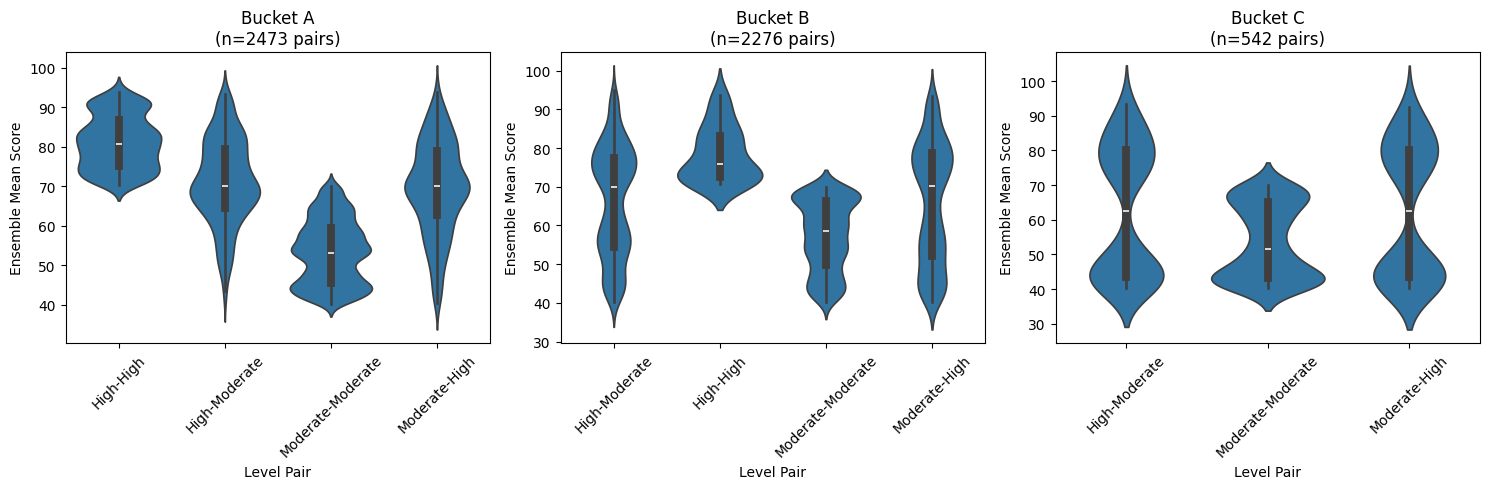

Score ranges by bucket and level:
  Bucket A, Level Pair High-High: n_pairs=253, score range=70.2–93.8, mean=81.1
  Bucket A, Level Pair High-Moderate: n_pairs=305, score range=41.7–93.3, mean=71.2
  Bucket A, Level Pair Moderate-High: n_pairs=236, score range=40.5–93.8, mean=69.4
  Bucket A, Level Pair Moderate-Moderate: n_pairs=1679, score range=40.2–70.0, mean=53.3
  Bucket B, Level Pair High-High: n_pairs=20, score range=70.8–93.8, mean=78.4
  Bucket B, Level Pair High-Moderate: n_pairs=840, score range=40.2–95.0, mean=66.4
  Bucket B, Level Pair Moderate-High: n_pairs=781, score range=40.2–93.3, mean=65.9
  Bucket B, Level Pair Moderate-Moderate: n_pairs=635, score range=40.2–70.0, mean=57.5
  Bucket C, Level Pair High-Moderate: n_pairs=200, score range=40.3–93.3, mean=62.6
  Bucket C, Level Pair Moderate-High: n_pairs=155, score range=40.3–92.5, mean=62.4
  Bucket C, Level Pair Moderate-Moderate: n_pairs=187, score range=40.3–70.0, mean=53.7


In [14]:
# Score distribution by bucket and level combination
import seaborn as sns

# Reload data if needed
if 'out_df' not in globals():
    pair_csv = repo_root / 'notebooks'/'outputs' / 'intra_panel_rank_agreement' / run_dir.name / 'pairwise_rank_consensus.csv'
    out_df = pd.read_csv(pair_csv)

# Compute ensemble levels for mean_i and mean_j
out_df['level_i'] = out_df['mean_i'].apply(affinity_level_fixed)
out_df['level_j'] = out_df['mean_j'].apply(affinity_level_fixed)
out_df['level_pair'] = out_df['level_i'] + '-' + out_df['level_j']

# Melt to get score distributions
df_melted = pd.concat([
    out_df[['bucket', 'level_pair', 'mean_i']].rename(columns={'mean_i': 'score'}),
    out_df[['bucket', 'level_pair', 'mean_j']].rename(columns={'mean_j': 'score'})
])

# Plot distributions for each bucket
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, bucket in enumerate(['A', 'B', 'C']):
    df_bucket = df_melted[df_melted['bucket'] == bucket]
    if len(df_bucket) == 0:
        axes[idx].text(0.5, 0.5, f'No data for Bucket {bucket}', ha='center', va='center')
        continue
    
    sns.violinplot(data=df_bucket, x='level_pair', y='score', ax=axes[idx], )
    axes[idx].set_title(f'Bucket {bucket}\n(n={len(out_df[out_df["bucket"]==bucket])} pairs)')
    axes[idx].set_xlabel('Level Pair')
    axes[idx].set_ylabel('Ensemble Mean Score')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print summary statistics
print('Score ranges by bucket and level:')
for bucket in ['A', 'B', 'C']:
    df_b = out_df[out_df['bucket'] == bucket]
    for lp in sorted(df_b['level_pair'].unique()):
        subset = df_b[df_b['level_pair'] == lp]
        scores = pd.concat([subset['mean_i'], subset['mean_j']])
        print(f"  Bucket {bucket}, Level Pair {lp}: n_pairs={len(subset)}, score range={scores.min():.1f}–{scores.max():.1f}, mean={scores.mean():.1f}")


## Discussion & Conclusions

### Key finding: boundary snapping in Bucket A

The violin plots reveal a **bimodal distribution within the Moderate-Moderate level pair (Bucket A)**: rather than scoring continuously across the Moderate band (40–70), models cluster near both edges — roughly 40–48 and 62–70 — with a trough around 50–60. The High-High pairs show a similar pattern near the High band edges (70–75 and 95–100).

This is the direct explanation for the low rank consensus in Bucket A (mean = 0.55) compared to Bucket B (0.79) and Bucket C (0.81):

- Two abstracts both labelled **Moderate** can have ensemble means of ~43 and ~67. When models are asked to rank them, some push the lower-scoring abstract into Low territory and others push the higher one into High, reversing their vote direction. The disagreement is a **measurement artefact driven by threshold position**, not genuine disagreement about relevance.
- In **Bucket B** (Moderate vs High), one abstract sits near ~45 and the other near ~80. The gap is large enough to survive each model's threshold idiosyncrasies, producing strong unanimity.

### Implication for calibration strategy

Score offset correction (re-centring each model's mean by a constant shift) assumes a continuously distributed signal within each band. Bimodality breaks this assumption — the modes are structural, not noise, so shifting them preserves the gap between the two clusters rather than collapsing it.

The appropriate strategy is **empirical threshold fitting**:
1. For each model, estimate the score value where it actually transitions from Moderate→High (and Low→Moderate), rather than assuming the nominal thresholds (40 / 70).
2. Use fitted per-model thresholds when assigning levels. This resolves most of the apparent label disagreement in Bucket A without requiring expert annotation.
3. After fitting, re-run the rank consensus analysis: Bucket A consensus should rise toward Bucket B levels if the bimodality was threshold-driven.

This reverses the calibration priority suggested earlier: **empirical threshold fitting before score offset correction**, not after.

### Implications for expert annotation design

Expert annotation budget should concentrate on the **trough between the two modes** — approximately scores 50–60 in the Moderate band — since these are the genuinely ambiguous abstracts that threshold fitting alone cannot resolve. Abstracts that land clearly in either mode, or that cross boundaries cleanly (Bucket B pattern), can be resolved by the calibrated ensemble without expert labels.

The expert benchmark design (pair-based comparisons within RA panels) remains appropriate, but pair selection should **oversample from the trough region** to maximise the diagnostic value of each annotated pair.

In [15]:


# Compute majority-vote level per abstract (tie -> choose higher level)
def maj_level_for_group(sub):
    labs = sub['LLM_Affinity'].apply(affinity_level_fixed).dropna().tolist()
    if not labs:
        return None
    counts = Counter(labs)
    top_count = max(counts.values())
    top_labels = [lab for lab,c in counts.items() if c==top_count]
    order = {'Low':0,'Moderate':1,'High':2}
    return sorted(top_labels, key=lambda x: order.get(x, -1), reverse=True)[0]

maj = (
    ra_with_ensemble
    .groupby(['RA2025_ID','Abstract_Index_Norm'])
    .apply(maj_level_for_group)
    .rename('majority_vote_level')
    .reset_index()
)

df = ra_with_ensemble.merge(maj, on=['RA2025_ID','Abstract_Index_Norm'], how='left')
df = df.rename(columns={'Model_Slug':'model_id', 'LLM_Affinity':'score', 'Affinity_Mean':'ensemble_mean'})
df = df[['model_id','score','majority_vote_level','ensemble_mean']]

# Exclude Low as requested
df_plot = df[df['majority_vote_level'] != 'Low'].copy()
if df_plot.empty:
    raise RuntimeError("No data after excluding 'Low' — check inputs.")

# Optional: only keep models with at least min_samples scores to avoid many empty facets
min_samples = 10
model_counts = df_plot.groupby('model_id')['score'].count()
good_models = model_counts[model_counts >= min_samples].index.tolist()
if len(good_models) == 0:
    # fallback: keep all models
    good_models = df_plot['model_id'].unique().tolist()
df_plot = df_plot[df_plot['model_id'].isin(good_models)]



/tmp/ipykernel_1760/1384533811.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(maj_level_for_group)


In [16]:
# plot_data = df_plot.copy()

# g = sns.catplot(
#     data=plot_data,
#     kind="violin",
#     x="majority_vote_level",
#     y="score",
#     row="model_id",
#     height=1.0,
#     aspect=2.8,
#     cut=0,
#     inner="quartile",
#     linewidth=0.8,
#     sharex=True,
#     sharey=True,
#     legend=False,
# )

# g.set_titles(row_template="{row_name}")
# g.set_axis_labels("", "Score")
# for ax in g.axes.flat:
#     ax.tick_params(axis="x", rotation=45, labelsize=8)
#     ax.tick_params(axis="y", labelsize=8)

# g.fig.subplots_adjust(hspace=0.25)
# g.fig.set_size_inches(10, max(3, 1.2 * len(plot_data["model_id"].unique())))
# plt.show()
# # g = sns.FacetGrid(
# #     df_plot[df_plot.majority_vote_level != "low"],  # exclude low as before
# #     col="majority_vote_level",
# #     row="model_id",
# #     height=5
# # )
# # g.map(sns.violinplot, "score")

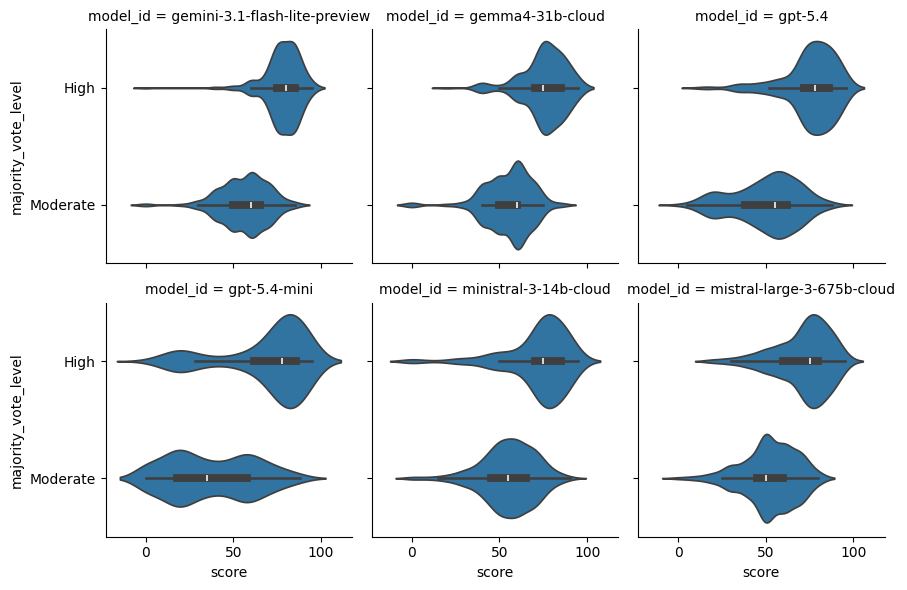

In [17]:
g = sns.catplot(
    df_plot,  # exclude low as before
    kind='violin',
    y='majority_vote_level',
    x='score',
    col='model_id',
    height=3,
    # aspect=2.8,
    col_wrap = 3,
    # col="majority_vote_level",
    # row="model_id",
    # height=2,
    # aspect=2.8,
)
plt.show()

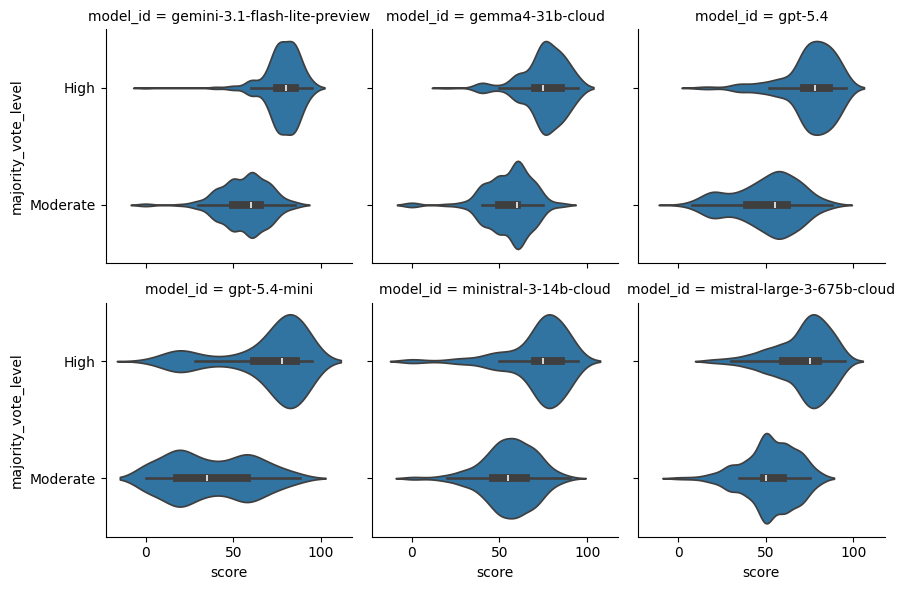

In [18]:
# Bucket A version of the same violin plots
# Keeps only abstracts that appear in Bucket A pairs (Moderate-Moderate / High-High)

bucket_a_pairs = out_df[out_df['bucket'] == 'A'][['RA2025_ID', 'abstract_i', 'abstract_j']].drop_duplicates()
bucket_a_abstracts = pd.unique(
    bucket_a_pairs[['abstract_i', 'abstract_j']]
    .astype(str)
    .to_numpy()
    .ravel()
)

bucket_a_df = (
    ra_with_ensemble
    .merge(
        maj[['RA2025_ID', 'Abstract_Index_Norm', 'majority_vote_level']],
        on=['RA2025_ID', 'Abstract_Index_Norm'],
        how='left'
    )
    .rename(columns={'Model_Slug': 'model_id', 'LLM_Affinity': 'score'})
)

bucket_a_plot = bucket_a_df[bucket_a_df['Abstract_Index_Norm'].astype(str).isin(bucket_a_abstracts)].copy()
bucket_a_plot = bucket_a_plot[bucket_a_plot['majority_vote_level'].isin(['Moderate', 'High'])].copy()

if bucket_a_plot.empty:
    raise RuntimeError('No Bucket A abstracts found for the violin plot.')

sns.catplot(
    data=bucket_a_plot,
    kind='violin',
    y='majority_vote_level',
    x='score',
    col='model_id',
    height=3,
    # aspect=2.8,
    col_wrap = 3,
)
plt.show()